In [10]:
# ============================================
# 1. Imports & Setup
# ============================================
import sys, os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_poisson_deviance, make_scorer
from preprocessing.preprocessing_utils import preprocess_for_tree


In [11]:
# ============================================
# 2. Data Loading & Preprocessing
# ============================================

# Load data (Assuming paths are correct)
train = pd.read_csv("../data/claims_train.csv")
test  = pd.read_csv("../data/claims_test.csv")

# Preprocess (External function)
X_tr, y_tr_rate, w_tr = preprocess_for_tree(train)
X_te, y_te_rate, w_te = preprocess_for_tree(test)
feature_names = list(X_tr.columns) 
print(f"Feature names extracted: {feature_names}")

# Convert to numpy for sklearn efficiency
X_train = X_tr.values.astype(np.float32)
y_train = y_tr_rate.values.astype(np.float32)
w_train = w_tr.values.astype(np.float32)

X_test = X_te.values.astype(np.float32)
y_test = y_te_rate.values.astype(np.float32)
w_test = w_te.values.astype(np.float32)

print(f"Training Shape: {X_tr.shape}")
print(f"Testing Shape:  {X_test.shape}")

Feature names extracted: ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area_Int', 'VehBrand_B10', 'VehBrand_B11', 'VehBrand_B12', 'VehBrand_B13', 'VehBrand_B14', 'VehBrand_B2', 'VehBrand_B3', 'VehBrand_B4', 'VehBrand_B5', 'VehBrand_B6', 'VehGas_Regular', 'Region_R21', 'Region_R22', 'Region_R23', 'Region_R24', 'Region_R25', 'Region_R26', 'Region_R31', 'Region_R41', 'Region_R42', 'Region_R43', 'Region_R52', 'Region_R53', 'Region_R54', 'Region_R72', 'Region_R73', 'Region_R74', 'Region_R82', 'Region_R83', 'Region_R91', 'Region_R93', 'Region_R94']
Training Shape: (542410, 38)
Testing Shape:  (135603, 38)


In [17]:
# ============================================
# 3. Evaluation & Plotting Functions
# ============================================
def d_squared_poisson(y_true, y_pred, w):
    """
    Calculates D^2 (Percentage of Deviance Explained).
    Now prints the Model Deviance and Null Deviance explicitly.
    """
    # 1. Deviance of the model
    dev_model = mean_poisson_deviance(y_true, y_pred, sample_weight=w)
    
    # 2. Deviance of the null model (intercept only, weighted mean of y)
    y_bar = np.average(y_true, weights=w)
    y_null = np.full_like(y_true, y_bar)
    dev_null = mean_poisson_deviance(y_true, y_null, sample_weight=w)
    
    # 3. Calculate D^2
    d2 = 1 - (dev_model / dev_null)
    
    # --- PRINTING VALUES ---
    print(f"--- D^2 Calculation ---")
    print(f"Null Deviance (Baseline): {dev_null:.5f}")
    print(f"Model Deviance:           {dev_model:.5f}")
    print(f"D^2 Score:                {d2:.2%}")
    print(f"-----------------------")
    
    return d2

def plot_lorenz_curve(y_true, y_pred, w, title="Lorenz Curve"):
    """
    Standard Actuarial Gini coefficient visualization.
    Now prints AUC and Gini values.
    """
    # Sort by predicted risk
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    data = data.sort_values('Pred')
    
    # Cumulative distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
    # Gini Calculation
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc 
    
    # --- PRINTING VALUES ---
    print(f"--- Gini Calculation ---")
    print(f"Area Under Curve (AUC): {auc:.5f}")
    print(f"Gini Coefficient:       {gini:.5f}")
    print(f"------------------------")
    
    # Plotting
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random (Gini: 0.0)')
    plt.xlabel('Cumulative Exposure (sorted by Pred Risk)')
    plt.ylabel('Cumulative Actual Claims')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

def plot_calibration(y_true, y_pred, w, n_bins=10, title="Calibration Plot (Lift Chart)"):
    """
    Splits the data into risk bins (deciles) and compares 
    Average Predicted Risk vs Average Actual Risk.
    """
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    
    # Robust binning
    try:
        data['Bin'] = pd.qcut(data['Pred'], n_bins, duplicates='drop')
    except:
        data['Bin'] = pd.cut(data['Pred'], n_bins)
        
    # Calculate Weighted Averages for each bin
    grouped = data.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'AvgPred': np.average(x['Pred'], weights=x['Weight']),
            'AvgTrue': np.average(x['True'], weights=x['Weight']),
            'Exposure': x['Weight'].sum(),
            'Count': len(x)
        })
    )
    
    # --- PRINTING VALUES ---
    print(f"\n=== {title} Data ===")
    print_df = grouped.copy()
    print_df['Diff'] = print_df['AvgPred'] - print_df['AvgTrue']
    print_df['Error %'] = (print_df['Diff'] / print_df['AvgTrue']) * 100
    
    # Print formatted table
    print(print_df[['AvgPred', 'AvgTrue', 'Diff', 'Exposure']].to_string(float_format="%.4f"))
    print("========================================\n")
    
    # Plotting
    fig, ax1 = plt.subplots(figsize=(10, 6))
    x = np.arange(len(grouped))
    width = 0.35
    
    ax1.bar(x - width/2, grouped['AvgPred'], width, label='Predicted Rate', alpha=0.7)
    ax1.bar(x + width/2, grouped['AvgTrue'], width, label='Actual Rate', alpha=0.7)
    
    ax1.set_xlabel('Risk Groups (Low -> High)')
    ax1.set_ylabel('Claim Frequency')
    ax1.set_title(title)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i+1}" for i in x])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(x, grouped['Exposure'], color='red', linestyle='--', marker='o', label='Exposure Vol', alpha=0.3)
    ax2.set_ylabel('Total Exposure (Years)')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance"):
    """
    Visualizes and prints which features the LightGBM model relies on most.
    Handles both sklearn API (LGBMRegressor) and native API (Booster).
    """
    # 1. Get Importances based on model type
    if hasattr(model, 'feature_importances_'):
        # Scikit-learn API
        importances = model.feature_importances_
    elif hasattr(model, 'feature_importance'):
        # Native LightGBM API (Booster)
        # importance_type='gain' is often more accurate than 'split', but 'split' is default
        importances = model.feature_importance(importance_type='gain')
    else:
        print("Error: Model does not have feature importance attribute.")
        return

    # 2. Sort indices
    indices = np.argsort(importances)[::-1]
    
    # 3. Print Values
    print(f"\n=== {title} Scores ===")
    print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10}")
    print("-" * 40)
    
    top_n = min(15, len(feature_names))
    for i in range(top_n):
        idx = indices[i]
        print(f"{i+1:<5} {feature_names[idx]:<20} {importances[idx]:.5f}")
    print("========================================\n")
    
    # 4. Plot
    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.bar(range(top_n), importances[indices[:top_n]], align="center")
    plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
    plt.xlabel("Feature")
    plt.ylabel("Importance Score (Gain)")
    plt.tight_layout()
    plt.show()

In [15]:
# ============================================
# 4. High-Performance Ensemble Training (Slow Learning)
# ============================================
# Strategy: 
# 1. Use the best structural params found in your RandomizedSearch (num_leaves=50, etc.)
# 2. Lower learning_rate from 0.05 -> 0.005 (10x slower, but more precise)
# 3. Increase estimators to 10,000 (with early stopping)
# 4. Train 5 separate models on different data splits and AVERAGE predictions

from sklearn.model_selection import KFold

# A. Fixed Parameters (Based on your successful search results)
params = {
    'objective': 'poisson',
    'metric': 'poisson',
    'learning_rate': 0.005,       # The "Slow Learning" magic number
    'num_leaves': 50,             # From your best_params_
    'min_child_samples': 100,     # From your best_params_
    'subsample': 0.8,             # From your best_params_
    'colsample_bytree': 0.6,      # From your best_params_
    'reg_alpha': 0,               # From your best_params_
    'reg_lambda': 1.0,            # From your best_params_
    'n_jobs': -1,
    'verbosity': -1,
    'random_state': 42
}

# B. Prepare for Ensembling
n_folds = 5
kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

# Array to store sum of predictions (we will divide by n_folds later)
y_pred_ensemble = np.zeros(len(X_test))

# Store models if you want to inspect them later
models = []

print(f"Starting {n_folds}-Fold Ensemble Training...")

# C. Loop through Folds
for fold, (train_idx, val_idx) in enumerate(kf.split(X_tr, y_train)):
    print(f"\n--- Fold {fold+1} / {n_folds} ---")
    
    # 1. Create Fold Data
    # Use .iloc for pandas dataframe slicing to keep feature names
    X_t = X_tr.iloc[train_idx]
    y_t = y_train[train_idx]
    w_t = w_train[train_idx]
    
    X_v = X_tr.iloc[val_idx]
    y_v = y_train[val_idx]
    w_v = w_train[val_idx]
    
    # 2. Create LightGBM Datasets
    dtrain = lgb.Dataset(X_t, label=y_t, weight=w_t)
    dval = lgb.Dataset(X_v, label=y_v, weight=w_v, reference=dtrain)
    
    # 3. Train with Early Stopping
    model = lgb.train(
        params,
        dtrain,
        num_boost_round=10000,           # High ceiling, relies on early stopping
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=1000) # Less noise in output
        ]
    )
    
    models.append(model)
    
    # 4. Predict on Test Set immediately
    # Add 1/5th of the prediction to the total
    y_pred_ensemble += model.predict(X_test) / n_folds

print("\nEnsemble Training Complete!")

Starting 5-Fold Ensemble Training...

--- Fold 1 / 5 ---
Training until validation scores don't improve for 100 rounds
[1000]	train's poisson: 0.302544	valid's poisson: 0.311559
[2000]	train's poisson: 0.298403	valid's poisson: 0.310147
[3000]	train's poisson: 0.295899	valid's poisson: 0.309873
[4000]	train's poisson: 0.293823	valid's poisson: 0.309768
[5000]	train's poisson: 0.291854	valid's poisson: 0.309673
[6000]	train's poisson: 0.290074	valid's poisson: 0.309582
[7000]	train's poisson: 0.288391	valid's poisson: 0.309532
Early stopping, best iteration is:
[7523]	train's poisson: 0.28754	valid's poisson: 0.309517

--- Fold 2 / 5 ---
Training until validation scores don't improve for 100 rounds
[1000]	train's poisson: 0.305111	valid's poisson: 0.301541
[2000]	train's poisson: 0.301095	valid's poisson: 0.299912
[3000]	train's poisson: 0.298646	valid's poisson: 0.299549
[4000]	train's poisson: 0.296615	valid's poisson: 0.299372
[5000]	train's poisson: 0.294724	valid's poisson: 0.29923


--- M3: LightGBM Ensemble Performance ---
--- D^2 Calculation ---
Null Deviance (Baseline): 0.63304
Model Deviance:           0.57191
D^2 Score:                9.66%
-----------------------

=== M3: Ensemble Calibration Data ===
                                AvgPred  AvgTrue    Diff  Exposure
Bin                                                               
(0.007319999999999999, 0.0489]   0.0395   0.0385  0.0009 8382.6641
(0.0489, 0.0593]                 0.0544   0.0505  0.0039 7784.6538
(0.0593, 0.0676]                 0.0635   0.0572  0.0063 7654.0742
(0.0676, 0.0751]                 0.0714   0.0695  0.0019 7707.6113
(0.0751, 0.0822]                 0.0787   0.0751  0.0035 7825.6309
(0.0822, 0.0899]                 0.0859   0.0858  0.0001 7844.8667
(0.0899, 0.101]                  0.0950   0.0990 -0.0040 7225.0186
(0.101, 0.127]                   0.1122   0.1111  0.0011 6307.4668
(0.127, 0.192]                   0.1523   0.1583 -0.0060 5887.6694
(0.192, 2.944]                   

C:\Users\Emil\AppData\Local\Temp\ipykernel_9556\2853377175.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = data.groupby('Bin', observed=False).apply(


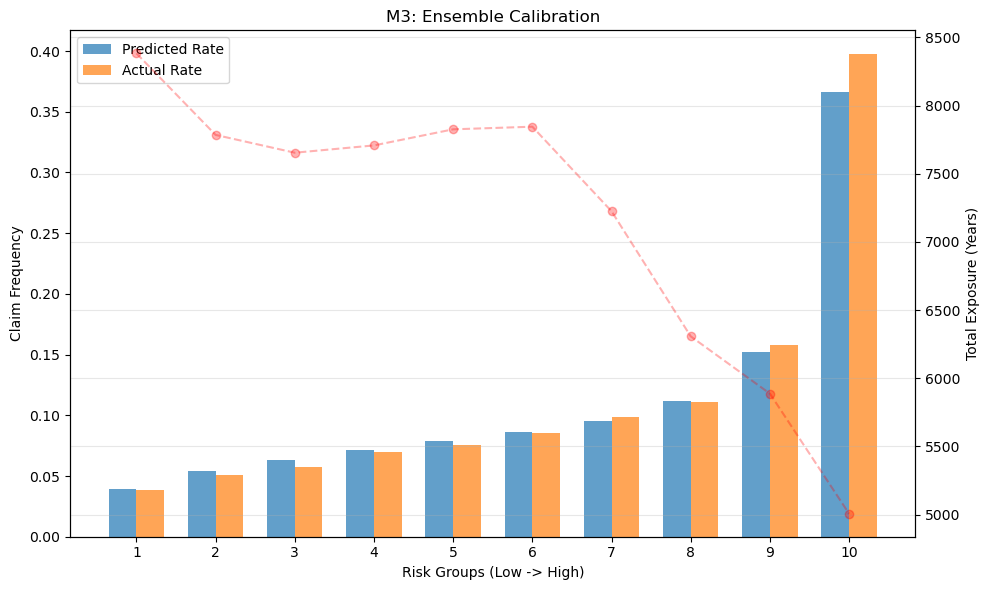

--- Gini Calculation ---
Area Under Curve (AUC): 0.31922
Gini Coefficient:       0.36156
------------------------


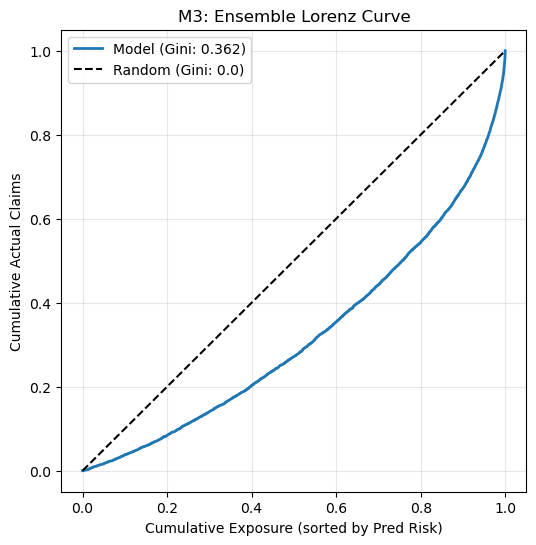


=== M3: Feature Importance (Fold 1) Scores ===
Rank  Feature              Importance
----------------------------------------
1     BonusMalus           495069.64442
2     VehAge               439375.48240
3     DrivAge              239431.64778
4     Density              215267.29904
5     VehPower             169248.19284
6     VehBrand_B12         124919.08972
7     VehGas_Regular       79815.49190
8     Area_Int             30041.03457
9     Region_R24           20379.87297
10    VehBrand_B2          18644.18240
11    Region_R91           11889.96877
12    VehBrand_B3          11080.89594
13    Region_R82           8444.25158
14    VehBrand_B6          7368.03475
15    Region_R93           7177.51908



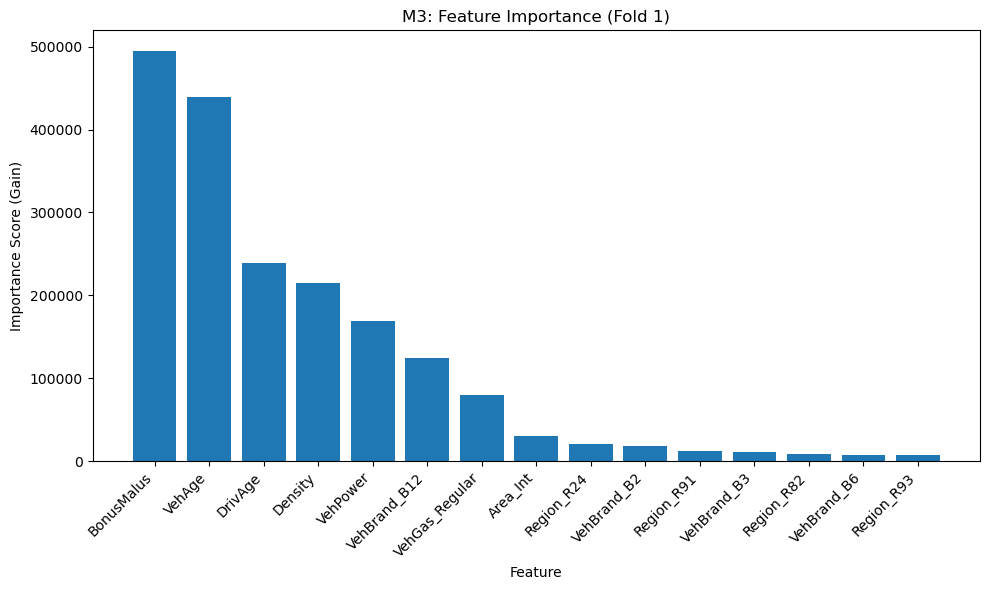

In [18]:
# ============================================
# 5. Final Evaluation
# ============================================

# --- A. D-SQUARED SCORE ---
print("\n--- M3: LightGBM Ensemble Performance ---")
d2_score = d_squared_poisson(y_test, y_pred_ensemble, w_test)

# --- B. CALIBRATION PLOT ---
plot_calibration(y_test, y_pred_ensemble, w_test, title="M3: Ensemble Calibration")

# --- C. LORENZ CURVE ---
plot_lorenz_curve(y_test, y_pred_ensemble, w_test, title="M3: Ensemble Lorenz Curve")

# --- D. FEATURE IMPORTANCE (Average of 5 models) ---
# We take the first model to plot importance (they are usually very similar)
plot_feature_importance(models[0], feature_names, title="M3: Feature Importance (Fold 1)")